In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The dataset contains 4.86M records obtained as the [AIMS].[LineWorkload], [Imports].[Line], [AIMS].[Direction] and [AIMS].[Entry] tables are combined and column [Original completion datetime] is restricted
to the financial year 2023/24.
If the column [Latest completion date] is used, the number of records rises to 5.09M.

The SQL script is shown below:

Loading the dataset (a gzipped CSV file) into a dataframe:

In [2]:
wload_df = pd.read_csv("./WorkloadLineDirectEntry.csv.gz",
                       parse_dates=['Initiating datetime', 'Original completion datetime', 'Latest completion datetime', 'Creation datetime'],
                       low_memory=False)

wload_df.sample(5)

,Line SK,Entry direction SK,Estimated workload,Initiating datetime,Original completion datetime,Latest completion datetime,Initiating type,Line number,Tariff ID,Goods description,...,Entry SK,Entry ID,Creation datetime,Entry hold reason,Direction mode,Document type ID,Arrival mode ID,Loading port code,Destination port code,Customs value
1782937,100395415,33063358,1.209677,2023-07-26 09:28:00,2023-07-31 12:53:00,2023-07-31 12:53:00,Q-Ruler,46,4015199096,RUBBER GLOVER-S,...,18930473,AEYTXTK94,2023-07-26 09:22:00,Dual,Line,FID,S,KRPUS,AUFRE,72900.82
2289415,104743925,34104485,0.151515,2024-01-17 07:50:00,2024-02-05 13:55:00,2024-02-15 14:15:00,Officer,45,1905900060,GARUDA SNACK CRACKERS GARLIC FLAVOUR (KACANG K...,...,19426548,AE4MPJN3C,2024-01-12 14:37:00,Dual,Container,FID,S,IDJKT,AUADL,60219.05
1641107,100627839,33184884,0.262009,2023-08-09 14:11:00,2023-08-09 14:21:00,2023-08-17 10:21:00,Officer,310,3822199049,PN:561181 HU FOXP3 ALEXA 488 236A/E7 100TST,...,18959571,AEYYT6LEG,2023-08-07 15:14:00,Biosecurity,Line,FID,A,USIAD,AUSYD,59998.52
818526,102183068,33598621,5.454545,2023-10-18 11:16:00,2023-10-27 11:21:00,2023-10-27 11:21:00,Officer,11,1209910004,CUCUMBER SEED - LOT MEL-1206-4520A,...,19152626,AE3NNNYG9,2023-10-12 12:10:00,Biosecurity,Line,FID,A,USORD,AUMEL,9413.10
4144189,104988509,34154676,7.500000,2024-01-22 14:37:00,2024-01-22 14:39:00,2024-01-22 14:39:00,Officer,1,8705900027,PATRIOT 4350 AGRICULTURAL SPRAYER A/C #EQPL305...,...,19451546,AE4N7RTY7,2024-01-22 14:11:00,Biosecurity,Line,FID,S,USBAL,AUBNE,525948.98


Mixed string and integer value are present in Tariff ID column. Recasting all as string and then apply the category type to this and other columns with limited value choices:

In [3]:
wload_df['Tariff ID'] = wload_df['Tariff ID'].astype(str)

for c in ('Initiating type', 
          'Tariff ID', 
          # 'Goods description', 
          'Line hold reason', 
          'First country code', 
          'First quantity unit code', 
          'Entry ID',
          'Entry hold reason', 
          'Direction mode',	 
          'Document type ID', 
          'Arrival mode ID',
          'Loading port code', 
          'Destination port code'):
    wload_df[c] = wload_df[c].astype("category")

This action drastically reduced memory use by about 3GB:

In [4]:
wload_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4855255 entries, 0 to 4855254
Data columns (total 24 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Line SK                       int64         
 1   Entry direction SK            int64         
 2   Estimated workload            float64       
 3   Initiating datetime           datetime64[ns]
 4   Original completion datetime  datetime64[ns]
 5   Latest completion datetime    datetime64[ns]
 6   Initiating type               category      
 7   Line number                   int64         
 8   Tariff ID                     category      
 9   Goods description             category      
 10  Line hold reason              category      
 11  First country code            category      
 12  First quantity unit code      category      
 13  First quantity                float64       
 14  Entry SK                      int64         
 15  Entry ID                      ca

The statistics of numeric columns (albeit the "* SK" columns are just codes, without numeric significance):

In [5]:
wload_df.describe(include="number")

,Line SK,Entry direction SK,Estimated workload,Line number,First quantity,Entry SK,Customs value
count,4.855255e+06,4.855255e+06,4.855255e+06,4.855255e+06,4.844766e+06,4.855255e+06,4.763374e+06
mean,1.042228e+08,3.398119e+07,3.957938e+00,4.505994e+02,5.336460e+03,1.936411e+07,1.646339e+06
std,3.317917e+06,6.802845e+05,1.539529e+01,1.441524e+03,5.692389e+05,3.974443e+05,6.683115e+06
min,3.374000e+03,1.115824e+07,0.000000e+00,1.000000e+00,0.000000e+00,3.390187e+06,1.000000e-02
25%,1.017529e+08,3.341775e+07,1.293103e-01,6.000000e+00,1.000000e+00,1.910465e+07,4.471433e+04
50%,1.041400e+08,3.396279e+07,5.504587e-01,3.000000e+01,5.000000e+00,1.936466e+07,1.010139e+05
75%,1.066777e+08,3.454108e+07,2.812500e+00,1.190000e+02,1.320000e+02,1.963236e+07,3.576801e+05
max,1.109313e+08,3.520776e+07,3.150000e+03,6.426000e+03,3.920004e+08,1.994542e+07,1.482630e+09


Similarly for the datetimes:

In [6]:
wload_df.describe(include="datetime")

,Initiating datetime,Original completion datetime,Latest completion datetime,Creation datetime
count,4855255,4855255,4855255,4855255
mean,2023-12-27 10:52:59.676980736,2023-12-31 10:33:17.353817344,2024-01-05 02:21:12.920578560,2023-12-22 19:10:24.708568832
min,2020-11-25 08:51:00,2023-07-01 01:07:00,2023-07-01 06:17:00,2009-12-21 13:37:00
25%,2023-10-02 22:09:00,2023-10-05 17:07:00,2023-10-09 09:56:00,2023-09-26 09:25:00
50%,2023-12-27 08:48:00,2023-12-30 13:25:00,2024-01-04 13:58:00,2023-12-20 08:46:00
75%,2024-03-24 13:12:00,2024-03-27 12:00:00,2024-04-02 13:57:00,2024-03-20 09:30:00
max,2024-06-30 22:25:00,2024-06-30 22:47:00,2025-01-21 14:19:00,2024-06-30 19:59:00


And finally the categorical columns:

In [7]:
wload_df.describe(exclude=["number", "datetime"])

,Initiating type,Tariff ID,Goods description,Line hold reason,First country code,First quantity unit code,Entry ID,Entry hold reason,Direction mode,Document type ID,Arrival mode ID,Loading port code,Destination port code
count,4855255,4855255,4855255,4855255,4854355,4844766,4855255,4855255,4855255,4855255,4855255,4855255,4851714
unique,3,6580,1216688,4,233,50,432998,3,2,8,4,3016,183
top,Officer,0000000000,PERSONAL EFFECTS,Biosecurity,CN,NO,AEYNA4GPA,Biosecurity,Line,FID,S,USLAX,AUMEL
freq,3516426,304273,11907,3403055,1357339,2077305,8804,4127686,3059704,4737529,4280370,338831,1655863


The most common Entry ID "AEYNA4GPA" is a consignment of Nissan Navara utes by a business in Melb, ordered in 13 batches in Jul-Aug 2023, shipped on a vessel named "Silver Queen" from a port near Pattaya, with an estimated Customs value of $31.5k each. The 'Goods description' column provides the VIN/chasis number, e.g. MNTABAD23A0001599, which can be googled to find the actual vehicle.

In [8]:
with pd.option_context("display.max_columns", None):
    display(wload_df.query('`Entry ID` == "AEYNA4GPA"').sort_values(by=['Entry direction SK', 'Line SK', 'Line number'], ascending=True))

,Line SK,Entry direction SK,Estimated workload,Initiating datetime,Original completion datetime,Latest completion datetime,Initiating type,Line number,Tariff ID,Goods description,Line hold reason,First country code,First quantity unit code,First quantity,Entry SK,Entry ID,Creation datetime,Entry hold reason,Direction mode,Document type ID,Arrival mode ID,Loading port code,Destination port code,Customs value
4050904,100328459,33058812,0.030000,2023-07-26 14:05:00,2023-07-31 09:43:00,2023-07-31 09:43:00,Officer,3,8704211079,NISSAN NAVARA MNTABAD23A0001599,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
3337180,100328460,33058812,0.030000,2023-07-26 14:05:00,2023-07-31 09:43:00,2023-07-31 09:43:00,Officer,8,8704211079,NISSAN NAVARA MNTABAD23A0001605,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
242149,100328461,33058812,0.030000,2023-07-26 14:05:00,2023-07-31 09:43:00,2023-07-31 09:43:00,Officer,9,8704211079,NISSAN NAVARA MNTABAD23A0001609,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
4302028,100328462,33058812,0.030000,2023-07-26 14:05:00,2023-07-31 09:43:00,2023-07-31 09:43:00,Officer,13,8704211079,NISSAN NAVARA MNTABAD23A0001622,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
4813214,100328463,33058812,0.030000,2023-07-26 14:05:00,2023-07-31 09:43:00,2023-07-31 09:43:00,Officer,14,8704211079,NISSAN NAVARA MNTABAD23A0001623,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031202,100339548,33166168,1.034483,2023-08-18 13:09:00,2023-08-24 13:01:00,2023-08-24 13:01:00,Officer,882,8704211079,NISSAN NAVARA MNTCBND23A0028480,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
1149896,100339550,33166168,1.034483,2023-08-18 13:09:00,2023-08-24 13:01:00,2023-08-24 13:01:00,Officer,891,8704211079,NISSAN NAVARA MNTCBND23A0028617,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
1647098,100339558,33166168,1.034483,2023-08-18 13:09:00,2023-08-24 13:01:00,2023-08-24 13:01:00,Officer,928,8704211079,NISSAN NAVARA MNTCBND23A0028100,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
1966494,100339560,33166168,1.034483,2023-08-18 13:09:00,2023-08-24 13:01:00,2023-08-24 13:01:00,Officer,930,8704211079,NISSAN NAVARA MNTCBND23A0028119,Biosecurity,TH,NO,1.0,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0


Each of the 13 batches has a breakbulk non-commodity ("B/B Non-Commodity") record with a Tariff ID "0000000000" and Line number 6000:

In [9]:
wload_df.query('`Entry ID` == "AEYNA4GPA"').groupby('Tariff ID', observed=True)['Line SK'].count()

Tariff ID
0000000000      13
8704211079    8791
Name: Line SK, dtype: int64

In [10]:
wload_df.query('`Entry ID` == "AEYNA4GPA"').query('`Tariff ID` == "0000000000"')

,Line SK,Entry direction SK,Estimated workload,Initiating datetime,Original completion datetime,Latest completion datetime,Initiating type,Line number,Tariff ID,Goods description,...,Entry SK,Entry ID,Creation datetime,Entry hold reason,Direction mode,Document type ID,Arrival mode ID,Loading port code,Destination port code,Customs value
2328214,100339578,33166168,1.034483,2023-08-18 13:09:00,2023-08-24 13:01:00,2023-08-24 13:01:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333697,100339578,33166167,0.570749,2023-08-04 14:05:00,2023-08-07 13:28:00,2023-08-07 13:28:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333698,100339578,33166166,0.063224,2023-08-04 10:37:00,2023-08-04 13:15:00,2023-08-04 13:15:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333699,100339578,33166165,0.061983,2023-08-02 12:48:00,2023-08-04 10:31:00,2023-08-04 10:31:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333700,100339578,33166164,0.720000,2023-07-24 11:08:00,2023-07-26 14:04:00,2023-07-26 14:04:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333701,100339578,33128330,0.461538,2023-08-11 11:46:00,2023-08-14 11:41:00,2023-08-14 11:41:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333702,100339578,33093689,0.545455,2023-08-15 14:11:00,2023-08-18 12:59:00,2023-08-18 12:59:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333703,100339578,33093688,0.317125,2023-08-09 14:12:00,2023-08-11 11:33:00,2023-08-11 11:33:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333704,100339578,33093687,0.550459,2023-08-07 13:46:00,2023-08-09 13:52:00,2023-08-09 13:52:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0
2333705,100339578,33093686,0.196721,2023-08-04 13:20:00,2023-08-04 13:54:00,2023-08-04 13:54:00,Officer,6000,0000000000,B/B Non-Commodity,...,18923000,AEYNA4GPA,2023-07-24 10:54:00,Biosecurity,Line,FID,S,THLCH,AUMEL,31490989.0


The Open Alalytics https://deptagriculture.sharepoint.com/teams/AG-OpenAnalytics/SitePages/Imported%20cargo%20pathway.aspx page, section g, Incidents states:

"Some incidents are recorded against NCCC lines (the ‘6000’ lines), which are actually containers masquerading as lines in order to leverage line-specific functionality in AIMS. For completeness, we retrieve the container number equivalent for each NCCC line, and conversely retrieve the NCCC line number equivalent for each container. These are then unioned with the validated line and container numbers directly tied to each incident so we have a complete picture of each incident from both a line and container perspective. In the Imported cargo pathway data model, we have included a dimension called ‘Incident item map method’ which indicates for users the provenance of each linked line and container value."

Aggregating the 13 batches shows the same Estimated workload for each line in the batch, and together they add up to multiples of 15 minutes, e.g. 30, 120, 90 etc...
Hence, each value was assigned based on this total workload in minutes, divided by the number of lines:

In [11]:
wload_df.query('`Entry ID` == "AEYNA4GPA"').groupby(['Entry direction SK', 'Initiating datetime']).agg(
    total=('Estimated workload', "count"),
    average=('Estimated workload', "mean"),
    median=('Estimated workload', "median"),
    stddev=('Estimated workload', lambda x: np.round(x.std(), 3)),
    tariff_dist=('Tariff ID', "unique"),
    count_x_avg=('Estimated workload', lambda x: np.round(x.count() * x.mean(), 5))
)

,,total,average,median,stddev,tariff_dist,count_x_avg
Entry direction SK,Initiating datetime,,,,,,
33058812,2023-07-26 14:05:00,1000,0.030000,0.030000,0.0,"['8704211079', '0000000000'] Categories (6580,...",30.00000
33058813,2023-08-14 11:41:00,325,0.369231,0.369231,0.0,"['8704211079', '0000000000'] Categories (6580,...",120.00000
33093685,2023-07-31 09:48:00,989,0.091001,0.091001,0.0,"['8704211079', '0000000000'] Categories (6580,...",90.00000
33093686,2023-08-04 13:20:00,915,0.196721,0.196721,0.0,"['8704211079', '0000000000'] Categories (6580,...",179.99999
33093687,2023-08-07 13:46:00,654,0.550459,0.550459,0.0,"['8704211079', '0000000000'] Categories (6580,...",359.99999
33093688,2023-08-09 14:12:00,473,0.317125,0.317125,0.0,"['8704211079', '0000000000'] Categories (6580,...",149.99999
33093689,2023-08-15 14:11:00,220,0.545455,0.545455,0.0,"['8704211079', '0000000000'] Categories (6580,...",120.00000
33128330,2023-08-11 11:46:00,325,0.461538,0.461538,0.0,"['8704211079', '0000000000'] Categories (6580,...",150.00000
33166164,2023-07-24 11:08:00,1000,0.720000,0.720000,0.0,"['8704211079', '0000000000'] Categories (6580,...",719.99998


It's interesting that in another private consignment of 40 bottles/casks of French wine, divided in two Entry directions of 20 each, the Estimated workload adds up to 15 and 30 minutes, respectively (0.75 * 20 and 1.5 * 20).
Hence, the total Estimated workload of 45 minutes thus exceeds that of the first batch of 1,000 utes (i.e., 30 min):

In [12]:
with pd.option_context("display.max_columns", None):
    display(wload_df.query('`Entry ID` == "AE4FT7KYP"').sort_values(by=['Entry direction SK', 'Line SK', 'Line number'], ascending=True))

,Line SK,Entry direction SK,Estimated workload,Initiating datetime,Original completion datetime,Latest completion datetime,Initiating type,Line number,Tariff ID,Goods description,Line hold reason,First country code,First quantity unit code,First quantity,Entry SK,Entry ID,Creation datetime,Entry hold reason,Direction mode,Document type ID,Arrival mode ID,Loading port code,Destination port code,Customs value
6327,103952210,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,1,2204212076,WINE,Food,FR,L,0.75,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
6326,103952211,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,2,2204212076,WINE,Food,FR,L,0.75,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
6329,103952212,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,3,2204212076,WINE,Food,FR,L,0.75,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
6324,103952213,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,4,2204212076,WINE,Food,FR,L,0.75,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
6331,103952214,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,5,2204212076,WINE,Food,FR,L,0.75,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
11220,103952215,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,6,2204212076,WINE,Food,FR,L,4.50,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
11218,103952216,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,7,2204212076,WINE,Food,FR,L,4.50,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
6323,103952217,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,8,2204212076,WINE,Food,FR,L,4.50,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
6318,103952218,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,9,2204212076,WINE,Food,FR,L,4.50,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84
11219,103952219,33951612,0.75,2024-01-11 12:28:00,2024-01-11 12:35:00,2024-12-11 15:05:00,Officer,10,2204212076,WINE,Food,FR,L,4.50,19345554,AE4FT7KYP,2023-12-13 16:59:00,Food,Line,FID,A,GBLHR,AUMEL,21073.84


The records with a Customs value exceeding $1G:

In [13]:
with pd.option_context("display.max_columns", None):
    display(wload_df.query('`Customs value` > 1e9').sort_values(by=['Entry direction SK', 'Line SK', 'Line number'], ascending=True))

,Line SK,Entry direction SK,Estimated workload,Initiating datetime,Original completion datetime,Latest completion datetime,Initiating type,Line number,Tariff ID,Goods description,Line hold reason,First country code,First quantity unit code,First quantity,Entry SK,Entry ID,Creation datetime,Entry hold reason,Direction mode,Document type ID,Arrival mode ID,Loading port code,Destination port code,Customs value
4017466,101536556,33347635,15.0,2023-09-20 13:52:00,2023-09-20 13:52:00,2023-09-20 13:52:00,Officer,1,9505900014,RAMSES AND THE GOLD OF THE PHARAOH,Biosecurity,EG,UN,1.0,19080852,AE3GPN3LN,2023-09-18 09:00:00,Biosecurity,Line,FID,A,BEBRU,AUSYD,1.482630e+09
1014408,103567769,33859237,15.0,2023-12-06 15:30:00,2023-12-06 15:37:00,2023-12-06 15:37:00,Officer,1,8906909044,"VESSEL ""CASTORONE V. 0112""",Biosecurity,CN,NO,1.0,19304585,AE4ALMEFA,2023-11-30 15:42:00,Biosecurity,Line,FID,O,SGSIN,AUDAM,1.214465e+09
675331,107930129,34828357,15.0,2024-05-08 21:24:00,2024-05-08 21:31:00,2024-05-08 21:31:00,Officer,1,9999301004,US SOFA GOODS ON GREEN COVE,Biosecurity,US,UN,1.0,19761731,AE6R6JTG3,2024-05-03 12:40:00,Biosecurity,Line,FID,S,USPEA,AUDRW,1.266674e+09
671605,107930129,34828358,180.0,2024-05-08 21:25:00,2024-05-11 14:38:00,2024-05-11 14:38:00,Officer,1,9999301004,US SOFA GOODS ON GREEN COVE,Biosecurity,US,UN,1.0,19761731,AE6R6JTG3,2024-05-03 12:40:00,Biosecurity,Line,FID,S,USPEA,AUDRW,1.266674e+09


There is no correllation between the Estimate workload and Custome value:

In [14]:
wload_df[['Estimated workload', 'Customs value']].corr()

,Estimated workload,Customs value
Estimated workload,1.000000,-0.045019
Customs value,-0.045019,1.000000


The total workload in man-hours for the 2023/24 financial year (log plot required to display amplitude past the initial peak):

In [15]:
round(wload_df['Estimated workload'].sum() / 60.0, 1)

320280.0

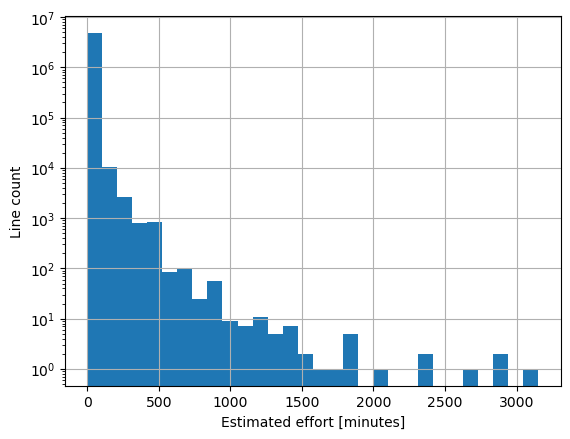

In [20]:
ax0 = wload_df['Estimated workload'].hist(bins=30, log=True)
ax0.set_xlabel("Estimated effort [minutes]")
ax0.set_ylabel("Line count");